In [5]:
import pandas as pd 
import numpy as numpy

In [6]:
df = pd.read_csv('placement.csv')

In [7]:
df.shape

(100, 4)

In [8]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [10]:
# iloc = integer-location based indexing in pandas
#  df.iloc[row_selection, column_selection]

df = df.iloc[:,1:]

In [11]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


### Steps:
0. Preprocess + EDA + Feature Selection
1. Extract input and output columns
2. Scale the values
3. Train Test split
4. Train the model
5. Evaluate the model / Model Selection
6. Deploy the model

In [12]:
import matplotlib.pyplot as plt

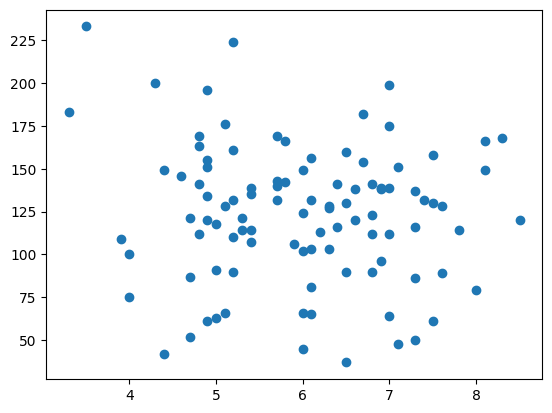

In [13]:
plt.scatter(df['cgpa'], df['iq'])

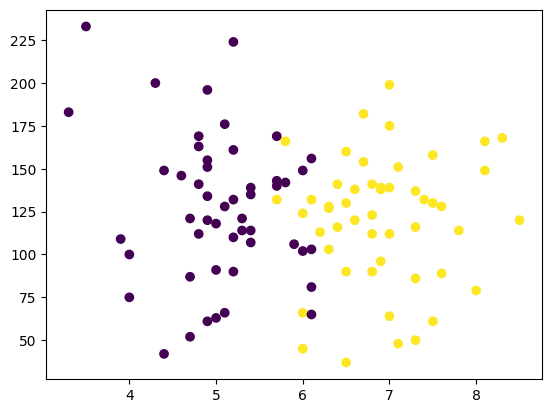

In [14]:
plt.scatter(df['cgpa'], df['iq'], c = df['placement'])

In [18]:
X = df.iloc[:, 0:2]
y = df.iloc[:, -1]

In [23]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [24]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [27]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1)

In [33]:
X_train

,cgpa,iq
51,4.8,141.0
26,7.0,199.0
10,6.0,45.0
32,7.0,139.0
12,5.4,139.0
...,...,...
9,5.1,66.0
20,6.6,120.0
68,4.0,75.0
70,6.3,127.0


In [34]:
X_test

,cgpa,iq
29,7.0,112.0
22,4.9,120.0
7,5.0,63.0
64,7.0,64.0
94,4.7,52.0
54,6.4,141.0
31,3.9,109.0
39,4.6,146.0
61,7.3,137.0
56,6.1,65.0


In [35]:
y_train

51    0
26    1
10    1
32    1
12    0
     ..
9     0
20    1
68    0
70    1
90    1
Name: placement, Length: 90, dtype: int64

In [36]:
y_test

29    1
22    0
7     0
64    1
94    0
54    1
31    0
39    0
61    1
56    0
Name: placement, dtype: int64

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
scalar = StandardScaler()

In [39]:
X_train = scalar.fit_transform(X_train)

In [40]:
X_train

array([[-1.0817676 ,  0.37742543],
       [ 0.86188017,  1.84659826],
       [-0.02159609, -2.0543089 ],
       [ 0.86188017,  0.3267643 ],
       [-0.55168184,  0.3267643 ],
       [ 0.9502278 , -1.9783172 ],
       [ 0.42014204, -2.25695343],
       [-1.7885486 , -0.66112777],
       [-0.81672472,  0.04812808],
       [-0.55168184, -0.48381381],
       [ 0.06675154,  0.14945034],
       [ 1.83370406,  0.58006996],
       [ 0.68518492, -0.91443343],
       [ 0.42014204,  0.85870619],
       [-0.99341997,  0.63073109],
       [-1.17011522, -0.12918589],
       [-0.72837709,  2.47986241],
       [ 1.74535643, -1.19306966],
       [-0.55168184, -0.30649985],
       [-0.64002947, -0.12918589],
       [ 0.86188017,  1.23866468],
       [-1.0817676 ,  0.93469788],
       [ 1.39196593,  0.04812808],
       [-0.99341997, -1.64901985],
       [ 0.9502278 ,  0.63073109],
       [ 0.59683729,  0.70672279],
       [ 0.42014204, -0.91443343],
       [-0.90507234, -0.20517758],
       [-0.81672472,

In [41]:
X_test = scalar.transform(X_test)

In [42]:
X_test

array([[ 0.86188017, -0.35716098],
       [-0.99341997, -0.15451645],
       [-0.90507234, -1.59835871],
       [ 0.86188017, -1.57302815],
       [-1.17011522, -1.87699494],
       [ 0.33179442,  0.37742543],
       [-1.87689623, -0.43315268],
       [-1.25846285,  0.50407826],
       [ 1.12692305,  0.27610317],
       [ 0.06675154, -1.54769758]])

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
clf = LogisticRegression()

In [ ]:
# model training
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [48]:
clf.predict(X_test)

array([1, 0, 0, 1, 0, 1, 0, 0, 1, 1], dtype=int64)

In [49]:
y_test

29    1
22    0
7     0
64    1
94    0
54    1
31    0
39    0
61    1
56    0
Name: placement, dtype: int64

In [50]:
y_pred = clf.predict(X_test)

In [51]:
from sklearn.metrics import accuracy_score

In [52]:
accuracy_score(y_test, y_pred)

0.9

In [53]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

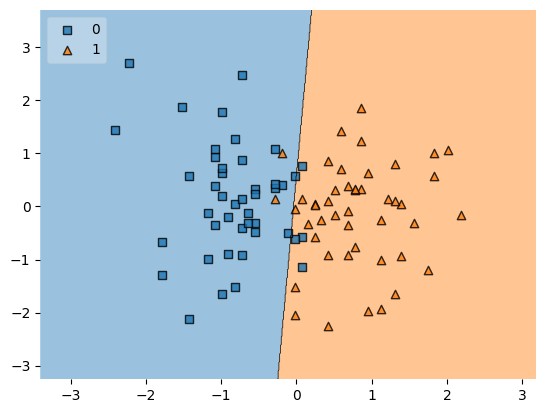

In [54]:
plot_decision_regions(X_train , y_train.values , clf=clf, legend = 2)

In [55]:
import pickle

In [56]:
pickle.dump(clf, open('model.pkl', 'wb'))